# 常用的数据清洗方法

在数据处理的过程中，一般都需要进行数据的清洗工作，如数据集是否存在重复、是否存在缺失、数据是否具有完整性和一致性、数据中是否存在异常值等．当发现数据中存在如上可能的问题时，都需要有针对性地处理，本节介绍如何识别和处理重复观测、缺失值和异常值.

### 1. 重复观测处理

重复观测是指观测行存在重复的现象，重复观测的存在会影响数据分析和挖掘结果的准确性，所以在数据分析和建模之前需要进行观测的重复性检验，如果存在重复观测，还需要进行重复项的删除.  
在搜集数据过程中，可能会存在重复观测， 例如，通过网络爬虫就比较容易产生重复数据如图4.9所示， 就是通过网络爬虫获得某APP市场中电商类APP的部分下载数据， 通过肉眼，是能够发现这 10 行数据中的重复项的， 例如，唯品会出现了两次、当当出现了三次．如果搜集上来的数据不是 10 行， 而是 10 万行， 就无法通过肉眼的方式检测数据是否存在重复项了．下面介绍如何运用 Pandas对读入的数据进行重复项检查， 以及如何删除数据中的重复项．

检测数据集的记录是否存在重复，Pandas 中使用 duplicated(重复) 方法， 该方法返回的是数据行每一行的检验结果， 即每一行返回一个 bool值． 使用 drop_duplicates 方法移除重复值（删除整行）.


In [4]:
import pandas as pd
a = pd.read_excel("Pdata4_26_1.xlsx")
print(f"是否存在重复观测：{any(a.duplicated())}")
a.drop_duplicates(inplace=True)  # inplace=True,直接删除a中的重复行数据
# 过时
# f = pd.ExcelWriter('Pdata4_26_3.xlsx')  # 创建文件对象
# a.to_excel(f)  # 把a写入新的Excel文件
# f.save()  # 保存文件，数据才真正的写入Excel文件
with pd.ExcelWriter('Pdata4_26_3.xlsx') as writer:
    a.to_excel(writer, index=False)

是否存在重复观测：True


### 2. 缺失值处理

数据缺失在大部分数据分析应用中都很常见， Pandas 使用浮点值 NaN 表示浮点或非浮点数组中的缺失数据， Python 内置的 None 值也会被当作缺失值处理．Pandas 使用方法 isnull 检测是否为缺失值， 检测对象的每个元素返回一个 bool 值．

In [6]:
from numpy import NaN
from pandas import Series
data = Series([10.0, None, 20, NaN, 30])
print(data.isnull())  # 输出每个元素的检测结果
print(f"是否存在缺失值：{any(data.isnull())}")  # 输出整体的检测结果，只要有缺失值，输出True

0    False
1     True
2    False
3     True
4    False
dtype: bool
是否存在缺失值：True


缺失值的处理可以采用三种方法， 分别是过滤法、填充法和插值法．  

过滤法又称删除法, 是指当缺失的观测比例非常低时（如 5％以内）， 直接删除存在缺失的观测； 或者当某些变量的缺失比例非常高时（如 85％以上）， 直接删除这些缺失的变量.

填充法又称替换法, 是指用某种常数直接替换那些缺失值，例如对连续变量而言，可以使用均值或中位数替换；对于离散变量，可以使用众数替换.

插值法, 是指根据其他非缺失的变量或观测来预测缺失值，常见的插值法有线性插值法、 K 近邻插值法、 Lagrange 插值法等

##### (1) 数据过滤

数据过滤方法 dropna 方法的语法格式如下：

dropna(axis=0, how='any', thresh=None)

其中:  
A. axis=0 表示删除行（记录）；axis=1 表示删除列（变量）  
B. how 参数可选值为 any 或 all, all 表示删除全有 NaN 的行  
C. thresh 为整数类型, 表示删除的条件, 如 thresh=3, 表示一行中至少有 3 个非 NaN 值, 才将其保留.

删除列的方式为 drop

In [14]:
import pandas as pd
a = pd.read_excel("Pdata2_33.xlsx", usecols=["用户A", "用户B", "用户C"])
b1 = a.dropna()  # 清空所有缺失值
b2 = a.dropna(axis=1, thresh=9)  # 清空有效数据个数小于9的列
b3 = a.drop('用户B', axis=1)  # 删除用户B的数据，删除列时要指定axis=1
print(b1, '\n-------------------\n', b2, '\n-------------------\n', b3)

      用户A     用户B      用户C
0  235.83  324.03  478.320
1  236.27  325.63  515.450
2  238.05  328.08  517.090
6  237.41  391.26  516.230
8  237.61  388.02  435.350
9  238.03  206.43  487.675 
-------------------
       用户A     用户B
0  235.83  324.03
1  236.27  325.63
2  238.05  328.08
3  235.90     NaN
4  236.76  268.82
5     NaN  404.04
6  237.41  391.26
7  238.65  380.81
8  237.61  388.02
9  238.03  206.43 
-------------------
       用户A     用户B     用户C
0  235.83  324.03  478.32
1  236.27  325.63  515.45
2  238.05  328.08  517.09
3  235.90     NaN  514.89
4  236.76  268.82     NaN
5     NaN  404.04  486.09
6  237.41  391.26  516.23
7  238.65  380.81     NaN
8  237.61  388.02  435.35


##### (2) 数据填充（fillna）

当数据中出现缺失值时，还可以用其他的数值进行填充．常用的方法是 fillna,
其基本语法格式为  
fillna(value=None, method=None, axis=None, inplace=False)   
其中 value 值除了基本类型外，还可以使用字典，这样可以实现对不同的列填充不同的值, method 表示采用的填补数据的方法, 默认是 None. 下面通过示例说明 fillna 的用法.


In [18]:
import pandas as pd
a = pd.read_excel("Pdata4_29.xlsx")
b1 = a.fillna(0)  # 用 0 填补所有的缺失值
b2 = a.fillna(method='ffill')  # 用前一行的值填补缺失值（forword）
b3 = a.fillna(method='bfill')  # 用后一行的值填补，最后一行缺失值不处理(behind)
b4 = a.fillna(value={'gender': a.gender.mode()[0],   # 众数替换
                     'age': a.age.mean(),   # 均值替换
                     'income': a.income.median()})  # 中位数替换
# 以数据框格式输出
print("b1 (用 0 填补):")
display(b1)
print("b2 (用前一行填补):")
display(b2)
print("b3 (用后一行填补，最后一行不做处理):")
display(b3)
print("b4 (用统计量填补):")
display(b4)

b1 (用 0 填补):


,uid,regit_date,gender,age,income
0,81200457,2016-10-30,M,23.0,6500.0
1,81201135,2016-11-08,M,27.0,10300.0
2,80043782,2016-10-13,F,0.0,13500.0
3,84639281,2017-04-17,M,26.0,6000.0
4,73499801,2016-03-21,0,0.0,4500.0
5,72399510,2016-01-18,M,19.0,0.0
6,63881943,2015-10-07,M,21.0,10000.0
7,35442690,2015-04-10,F,0.0,5800.0
8,77638351,2016-07-12,M,25.0,18000.0
9,85200189,2017-05-18,M,22.0,0.0


b2 (用前一行填补):


,uid,regit_date,gender,age,income
0,81200457,2016-10-30,M,23.0,6500.0
1,81201135,2016-11-08,M,27.0,10300.0
2,80043782,2016-10-13,F,27.0,13500.0
3,84639281,2017-04-17,M,26.0,6000.0
4,73499801,2016-03-21,M,26.0,4500.0
5,72399510,2016-01-18,M,19.0,4500.0
6,63881943,2015-10-07,M,21.0,10000.0
7,35442690,2015-04-10,F,21.0,5800.0
8,77638351,2016-07-12,M,25.0,18000.0
9,85200189,2017-05-18,M,22.0,18000.0


b3 (用后一行填补，最后一行不做处理):


,uid,regit_date,gender,age,income
0,81200457,2016-10-30,M,23.0,6500.0
1,81201135,2016-11-08,M,27.0,10300.0
2,80043782,2016-10-13,F,26.0,13500.0
3,84639281,2017-04-17,M,26.0,6000.0
4,73499801,2016-03-21,M,19.0,4500.0
5,72399510,2016-01-18,M,19.0,10000.0
6,63881943,2015-10-07,M,21.0,10000.0
7,35442690,2015-04-10,F,25.0,5800.0
8,77638351,2016-07-12,M,25.0,18000.0
9,85200189,2017-05-18,M,22.0,NaN


b4 (用统计量填补):


,uid,regit_date,gender,age,income
0,81200457,2016-10-30,M,23.000000,6500.0
1,81201135,2016-11-08,M,27.000000,10300.0
2,80043782,2016-10-13,F,23.285714,13500.0
3,84639281,2017-04-17,M,26.000000,6000.0
4,73499801,2016-03-21,M,23.285714,4500.0
5,72399510,2016-01-18,M,19.000000,8250.0
6,63881943,2015-10-07,M,21.000000,10000.0
7,35442690,2015-04-10,F,23.285714,5800.0
8,77638351,2016-07-12,M,25.000000,18000.0
9,85200189,2017-05-18,M,22.000000,8250.0


##### (3) 插值法

当出现缺失值时，也可以使用插值法对缺失值进行插补，插值的数学原理在第 7 章介绍， 其中的插值方法可以使用：'linear', 'nearest', 'zero',  'slinear' , 'quadratic' , 'cubic','spline', 'barycentric', 'polynomial' . 

In [19]:
import pandas as pd
a = pd.read_excel("Pdata4_29.xlsx")
# 一个Series可能有多个中数，mode()[0]取第一个众数填充
b = a.fillna(value={'gender': a.gender.mode()[0],  # 中位数替换
                    'age': a.age.interpolate(methed='polynomial', order=2),  # 二次多项式替换
                    'income': a.income.interpolate()})  # 线性插值替换
display(a)
display(b)

,uid,regit_date,gender,age,income
0,81200457,2016-10-30,M,23.0,6500.0
1,81201135,2016-11-08,M,27.0,10300.0
2,80043782,2016-10-13,F,NaN,13500.0
3,84639281,2017-04-17,M,26.0,6000.0
4,73499801,2016-03-21,NaN,NaN,4500.0
5,72399510,2016-01-18,M,19.0,NaN
6,63881943,2015-10-07,M,21.0,10000.0
7,35442690,2015-04-10,F,NaN,5800.0
8,77638351,2016-07-12,M,25.0,18000.0
9,85200189,2017-05-18,M,22.0,NaN


,uid,regit_date,gender,age,income
0,81200457,2016-10-30,M,23.0,6500.0
1,81201135,2016-11-08,M,27.0,10300.0
2,80043782,2016-10-13,F,26.5,13500.0
3,84639281,2017-04-17,M,26.0,6000.0
4,73499801,2016-03-21,M,22.5,4500.0
5,72399510,2016-01-18,M,19.0,7250.0
6,63881943,2015-10-07,M,21.0,10000.0
7,35442690,2015-04-10,F,23.0,5800.0
8,77638351,2016-07-12,M,25.0,18000.0
9,85200189,2017-05-18,M,22.0,18000.0


### 3. 异常值处理

异常值 (outlier) 是指那些远离正常值的观测，即“不合群＂观测．异常值的出现会对模型的创建和预测产生严重的后果．当然异常值的出现也不一定都是坏事，有些情况下，通过寻找异常值就能够给业务带来良好的发展，如销毁＂钓鱼＂网站，关闭“薅羊毛”用户的权限等。  

对于异常值的检测，一般采用两种方法，一种是标准差法，另一种是箱线图判别法.  
标准差法的判别公式是 $\text{outlier} > \bar{x} + n \sigma$ 或$\text{outlier} < \bar{x} - n \sigma$，其中$\bar{x}$为样本均值，$\sigma$为样本标准差. 当$n = 2$时，满足条件的观测就是异常值；当$n = 3$时，满足条件的观测即是极端异常值.  
箱线图的判别公式是 $\text{outlier} > Q_3 + n \text{IQR}$ 或 $\text{outlier} < Q_1 - n \text{IQR}$ ，其中 $Q_1$ 为下四分位数 ($25\%$)，$Q_3$ 为上四分位数 ($75\%$)，$\text{IQR}$ 为上四分位数与下四分位数的差. 当$n = 1.5$时，满足条件的观测为异常值；当 $n = 3$ 时，满足条件的观测即为极端异常值.  

这两种方法的选择标准如下，如果数据近似服从正态分布，因为数据的分布相对比较对称， 优先选择标准差法，否则优先选择箱线图法，因为分位数并不会受到极端值的影响当数据存在异常时，若异常观测的比例不太大，一般可以使用删除法将异常值删除； 也可以使用替换法，可以考虑使用低于判别上限的最大值替换上端异常值、高千判别下限的最小值替换下端异常值， 或使用均值或中位数替换等．

标准差法异常值上限检测：True
标准差法异常值下限检测：False
箱线图法异常值上限检测：True
箱线图法异常值下限检测：False


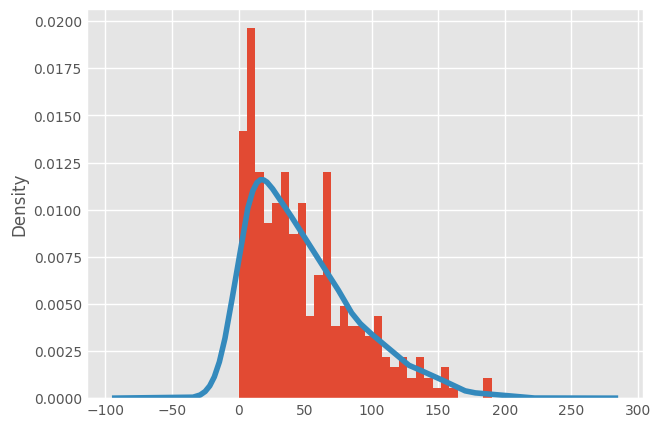

异常值替换前的数据统计特征：
count    289.000000
mean      48.613495
std       39.474103
min        0.000000
25%       15.600000
50%       39.000000
75%       68.900000
max      190.200000
Name: counts, dtype: float64
替换异常值的上限临界值为：148.85000000000002
用以替换异常值的数据为：141.7
异常值替换后的数据统计特征：
count    289.000000
mean      48.066090
std       37.918895
min        0.000000
25%       15.600000
50%       39.000000
75%       68.900000
max      141.700000
Name: counts, dtype: float64


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
a = pd.read_csv("sunspots.csv")
miu = a.counts.mean()  # 计算太阳黑子个数年平均值
s = a.counts.std()  # 计算太阳黑子个数的标准差
print(f"标准差法异常值上限检测：{any(a.counts > miu+2*s)}")
print(f"标准差法异常值下限检测：{any(a.counts < miu-2*s)}")
Q1 = a.counts.quantile(0.25)  # 下四分位数
Q3 = a.counts.quantile(0.75)  # 上四分位数
IQR = Q3 - Q1
print(f"箱线图法异常值上限检测：{any(a.counts > Q3+1.5*IQR)}")
print(f"箱线图法异常值下限检测：{any(a.counts < Q1-1.5*IQR)}")
plt.style.use('ggplot')  # 设置绘图风格
a.counts.plot(kind='hist', bins=30, density=True)  # 绘制直方图
a.counts.plot(kind='kde')  # 绘制核密度曲线
plt.show()
print(f"异常值替换前的数据统计特征：\n{a.counts.describe()}")
UB = Q3 + 1.5*IQR
st = a.counts[a.counts < UB].max()  # 找出低于判别上限的最大值
print(f"替换异常值的上限临界值为：{UB}")
print(f"用以替换异常值的数据为：{st}")
a.loc[a.counts > UB, 'counts'] = st  # 替换超过判别上限的异常值
print(f"异常值替换后的数据统计特征：\n{a.counts.describe()}")